In [ ]:
import os
import sys
# CaLRepo = os.environ.get("CaLRepo")
CaLRepo = '/home/zyq0416/workspace/CaL'
# print(CaLRepo)
sys.path.append(f"{CaLRepo}/utilities/")
import math
import json
import numpy as np
from pyCostEstimator import Cost_Estimator
from scipy.optimize import fsolve
## construct cost indictor
construct_labour_cost_indictor=0.25
engineering_project_cost_indictor=0.175
TASC_multiplier=1.13
piping_integration_cost_indictor=0.05
#单次储能时间8小时
Single_run_time=8*3600
#年循环次数（储能2560小时，释能2560小时，年运行时间5120小时
Annual_cycle_count = 320
#循环极限次数
Limit_cycle_number = 50
#安全存储比例

#氢氧化钙价格RMB/t
caoh2_unit_price=1500
M_cao = 56e-3  # kg/mol
M_caoh2 = 74e-3  # kg/mol
parameters = dict()
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["isentropic_eff_mc"] = 0.88
parameters["t_isentropic_eff_mc"] = 0.92
parameters["mechanical_eff"] = 0.98   #机械效率
parameters["industrial_waste_heat_t"] =300 #℃
parameters["heat_transfer_loss_eff"] = 0.96
parameters["t_amb"] = 20   #环境温度
parameters["p_amb"] = 101325   #环境压力

parameters["p_bray_L"] = 7.5e6
parameters["Store_electrical_power"] = 50e6  # 机组容量
parameters["p_water_supply_in"] = 2e5 
parameters["water_pressure_drop_rate"] = 100 #100Pa/m
parameters["water_pipe_length"] = 1000
parameters["water_pump_hydraulic_efficiency"] = 0.75
parameters["water_pump_mechanical_efficiency"] = 0.94

parameters["cao_conversion"] = 0.95  #氧化钙转化率
parameters["cao_purity"] = 0.98 #氢氧化钙含量
parameters["dehydrator_eff"] = 0.95   #脱水器效率
parameters["steam_pressure_loss_ratio"] = 0.01
parameters["convey_consumption"] = 10e3/100
parameters["storage_dehydrator_distance"] = 100

parameters["hydrator_eff"] = 0.95   #水合器器效率
parameters["p_bray_L_B"] = 7.5e6

inputs={}
inputs["p_bray_H"] = 18716228#优化变量1，热泵循环最高压力
inputs["p_bray_M"] = 12481150 #优化变量2，热泵循环中间压力
inputs["p_Dehy"] = 1e5 #变量4，反应器压力
inputs["Economic Model Selection"] = 1 #经济模型选择，1Tesio，2Nathan T
inputs["Compressor power limit"] = 200e6#功率界限，影响齿轮离心和滚筒离心模型的选取，单位W，桶式离心需体积流量
inputs["Turbine power limit"] = 35e6
inputs["Dehy_overheating_temperature"] = 20 #变量2，脱水反应器过热温度
inputs["min_temperature_exchange"] = 15
inputs["min_temperature_HEN"] = 15

inputs["p_bray_H_B"] = 30e6
inputs["p_bray_MH_B"] = 16217752.142109105
inputs["p_bray_ML_B"] = 12217752.142109105
inputs["p_Hydr"] = 1e5
inputs["Hydr_overheating_temperature"] = 40

inputs["Hydr_cao_in"]=440
inputs["T_X"] = 1


economic_inputs={}
#economic_inputs["limestone_price"]=70
#economic_inputs["calciner_cost_factor"]=1
economic_inputs["elec_price"]=0 #元/千瓦时  ##S6
economic_inputs["hot_price_h"] = 0.1542 #每千瓦时0.1542元，42.84元/吉焦
economic_inputs["elec_price_h"] = 1.0827
economic_inputs["operation_hours"]=2560 # hours  ### S9
economic_inputs["discount_ratio"]=6/100 #8%
economic_inputs["operational_years"]=60
economic_inputs["operation_labour_cost_indictor"]=0.025/2*(2/3)/2 #劳动力比例
#年运行时间为一般机组的一半,天运行时间为一般机组的2/3，投资成本为一般机组的两倍以上
economic_inputs["maintain_cost_indictor"]=0.025/2/2 #维护比例 0.025,
#年运行时间为一般机组的一半，投资成本为一般机组的两倍以上故修正

cost = Cost_Estimator(parameters)
results = cost.solve(inputs,economic_inputs)
#print(json_output)
a=results["construction"]["total as-spent"]
b=results["operation"]["total as-spent"]
c=results["Annual_operating_income"]
d=results["IRR"]


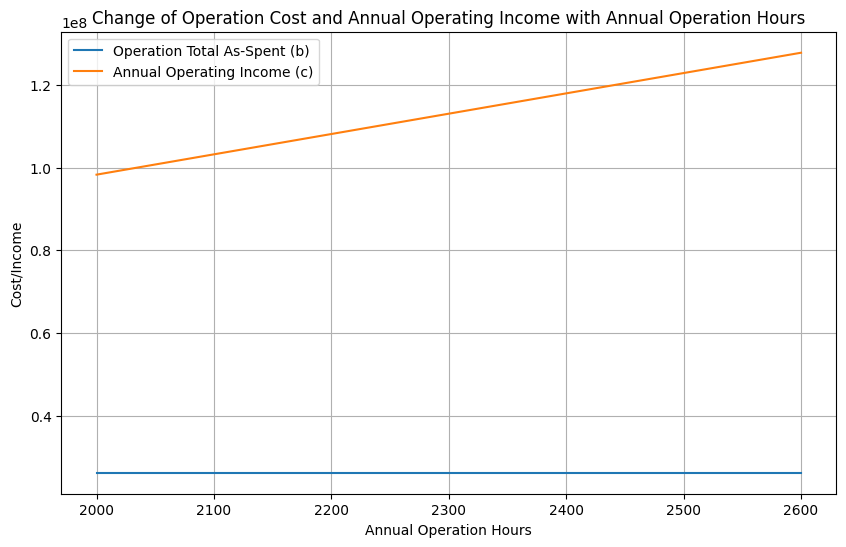

In [4]:
import os
import sys
# CaLRepo = os.environ.get("CaLRepo")
CaLRepo = '/home/zyq0416/workspace/CaL'
# print(CaLRepo)
sys.path.append(f"{CaLRepo}/utilities/")
import math
import json
import numpy as np
from pyCostEstimator import Cost_Estimator
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

## construct cost indictor
construct_labour_cost_indictor = 0.25
engineering_project_cost_indictor = 0.175
TASC_multiplier = 1.13
piping_integration_cost_indictor = 0.05
# 单次储能时间8小时
Single_run_time = 8 * 3600
# 年循环次数（储能2560小时，释能2560小时，年运行时间5120小时
Annual_cycle_count = 320
# 循环极限次数
Limit_cycle_number = 50
# 安全存储比例

# 氢氧化钙价格RMB/t
caoh2_unit_price = 1500
M_cao = 56e-3  # kg/mol
M_caoh2 = 74e-3  # kg/mol
parameters = dict()
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["isentropic_eff_mc"] = 0.88
parameters["t_isentropic_eff_mc"] = 0.92
parameters["mechanical_eff"] = 0.98   # 机械效率
parameters["industrial_waste_heat_t"] = 300  # ℃
parameters["heat_transfer_loss_eff"] = 0.96
parameters["t_amb"] = 20   # 环境温度
parameters["p_amb"] = 101325   # 环境压力

parameters["p_bray_L"] = 7.5e6
parameters["Store_electrical_power"] = 50e6  # 机组容量
parameters["p_water_supply_in"] = 2e5
parameters["water_pressure_drop_rate"] = 100  # 100Pa/m
parameters["water_pipe_length"] = 1000
parameters["water_pump_hydraulic_efficiency"] = 0.75
parameters["water_pump_mechanical_efficiency"] = 0.94

parameters["cao_conversion"] = 0.95  # 氧化钙转化率
parameters["cao_purity"] = 0.98  # 氢氧化钙含量
parameters["dehydrator_eff"] = 0.95   # 脱水器效率
parameters["steam_pressure_loss_ratio"] = 0.01
parameters["convey_consumption"] = 10e3 / 100
parameters["storage_dehydrator_distance"] = 100

parameters["hydrator_eff"] = 0.95   # 水合器器效率
parameters["p_bray_L_B"] = 7.5e6

inputs = {}
inputs["p_bray_H"] = 18716228  # 优化变量1，热泵循环最高压力
inputs["p_bray_M"] = 12481150  # 优化变量2，热泵循环中间压力
inputs["p_Dehy"] = 1e5  # 变量4，反应器压力
inputs["Economic Model Selection"] = 1  # 经济模型选择，1Tesio，2Nathan T
inputs["Compressor power limit"] = 200e6  # 功率界限，影响齿轮离心和滚筒离心模型的选取，单位W，桶式离心需体积流量
inputs["Turbine power limit"] = 35e6
inputs["Dehy_overheating_temperature"] = 20  # 变量2，脱水反应器过热温度
inputs["min_temperature_exchange"] = 15
inputs["min_temperature_HEN"] = 15

inputs["p_bray_H_B"] = 30e6
inputs["p_bray_MH_B"] = 16217752.142109105
inputs["p_bray_ML_B"] = 12217752.142109105
inputs["p_Hydr"] = 1e5
inputs["Hydr_overheating_temperature"] = 40

inputs["Hydr_cao_in"] = 440
inputs["T_X"] = 1

economic_inputs = {}
# economic_inputs["limestone_price"]=70
# economic_inputs["calciner_cost_factor"]=1
economic_inputs["elec_price"] = 0  # 元/千瓦时  ##S6
economic_inputs["hot_price_h"] = 0.1542  # 每千瓦时0.1542元，42.84元/吉焦
economic_inputs["elec_price_h"] = 1.0827
# economic_inputs["operation_hours"]=2560 # hours  ### S9
economic_inputs["discount_ratio"] = 6 / 100  # 8%
economic_inputs["operational_years"] = 60
economic_inputs["operation_labour_cost_indictor"] = 0.025 / 2 * (2 / 3) / 2  # 劳动力比例
# 年运行时间为一般机组的一半,天运行时间为一般机组的2/3，投资成本为一般机组的两倍以上
economic_inputs["maintain_cost_indictor"] = 0.025 / 2 / 2  # 维护比例 0.025,
# 年运行时间为一般机组的一半，投资成本为一般机组的两倍以上故修正

operation_hours_list = np.arange(2000, 2601, 100)
b_values = []
c_values = []

cost = Cost_Estimator(parameters)
for hours in operation_hours_list:
    economic_inputs["operation_hours"] = hours
    results = cost.solve(inputs, economic_inputs)
    b = results["operation"]["total as-spent"]
    c = results["Annual_operating_income"]
    b_values.append(b)
    c_values.append(c)

plt.figure(figsize=(10, 6))
plt.plot(operation_hours_list, b_values, label='Operation Total As-Spent (b)')
plt.plot(operation_hours_list, c_values, label='Annual Operating Income (c)')
plt.xlabel('Annual Operation Hours')
plt.ylabel('Cost/Income')
plt.title('Change of Operation Cost and Annual Operating Income with Annual Operation Hours')
plt.legend()
plt.grid(True)
plt.show()

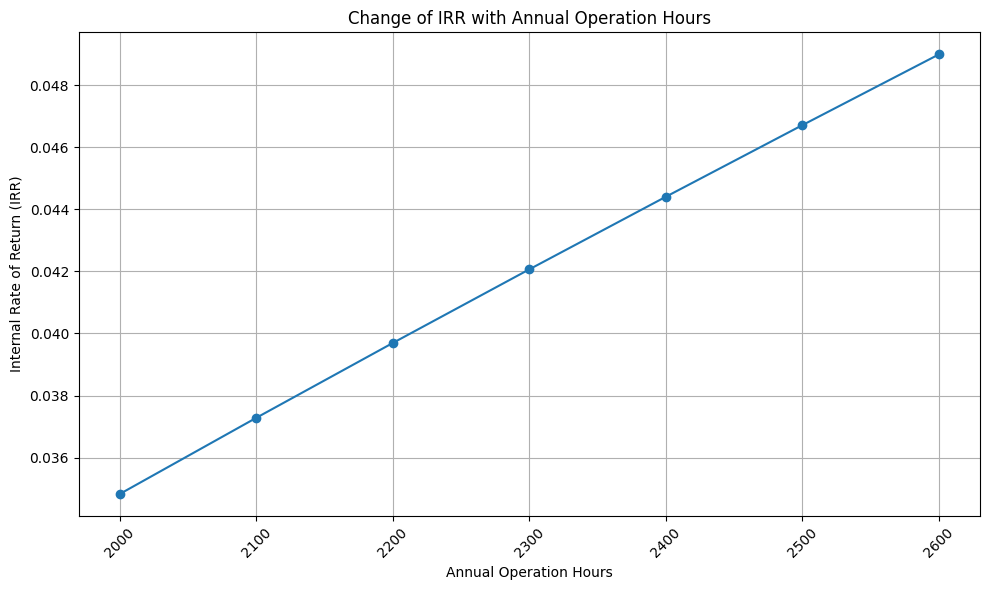

In [5]:
import os
import sys
# CaLRepo = os.environ.get("CaLRepo")
CaLRepo = '/home/zyq0416/workspace/CaL'
# print(CaLRepo)
sys.path.append(f"{CaLRepo}/utilities/")
import math
import json
import numpy as np
from pyCostEstimator import Cost_Estimator
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

## construct cost indictor
construct_labour_cost_indictor = 0.25
engineering_project_cost_indictor = 0.175
TASC_multiplier = 1.13
piping_integration_cost_indictor = 0.05
# 单次储能时间8小时
Single_run_time = 8 * 3600
# 年循环次数（储能2560小时，释能2560小时，年运行时间5120小时
Annual_cycle_count = 320
# 循环极限次数
Limit_cycle_number = 50
# 安全存储比例

# 氢氧化钙价格RMB/t
caoh2_unit_price = 1500
M_cao = 56e-3  # kg/mol
M_caoh2 = 74e-3  # kg/mol
parameters = dict()
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["isentropic_eff_mc"] = 0.88
parameters["t_isentropic_eff_mc"] = 0.92
parameters["mechanical_eff"] = 0.98   # 机械效率
parameters["industrial_waste_heat_t"] = 300  # ℃
parameters["heat_transfer_loss_eff"] = 0.96
parameters["t_amb"] = 20   # 环境温度
parameters["p_amb"] = 101325   # 环境压力

parameters["p_bray_L"] = 7.5e6
parameters["Store_electrical_power"] = 50e6  # 机组容量
parameters["p_water_supply_in"] = 2e5
parameters["water_pressure_drop_rate"] = 100  # 100Pa/m
parameters["water_pipe_length"] = 1000
parameters["water_pump_hydraulic_efficiency"] = 0.75
parameters["water_pump_mechanical_efficiency"] = 0.94

parameters["cao_conversion"] = 0.95  # 氧化钙转化率
parameters["cao_purity"] = 0.98  # 氢氧化钙含量
parameters["dehydrator_eff"] = 0.95   # 脱水器效率
parameters["steam_pressure_loss_ratio"] = 0.01
parameters["convey_consumption"] = 10e3 / 100
parameters["storage_dehydrator_distance"] = 100

parameters["hydrator_eff"] = 0.95   # 水合器器效率
parameters["p_bray_L_B"] = 7.5e6

inputs = {}
inputs["p_bray_H"] = 18716228  # 优化变量1，热泵循环最高压力
inputs["p_bray_M"] = 12481150  # 优化变量2，热泵循环中间压力
inputs["p_Dehy"] = 1e5  # 变量4，反应器压力
inputs["Economic Model Selection"] = 1  # 经济模型选择，1Tesio，2Nathan T
inputs["Compressor power limit"] = 200e6  # 功率界限，影响齿轮离心和滚筒离心模型的选取，单位W，桶式离心需体积流量
inputs["Turbine power limit"] = 35e6
inputs["Dehy_overheating_temperature"] = 20  # 变量2，脱水反应器过热温度
inputs["min_temperature_exchange"] = 15
inputs["min_temperature_HEN"] = 15

inputs["p_bray_H_B"] = 30e6
inputs["p_bray_MH_B"] = 16217752.142109105
inputs["p_bray_ML_B"] = 12217752.142109105
inputs["p_Hydr"] = 1e5
inputs["Hydr_overheating_temperature"] = 40

inputs["Hydr_cao_in"] = 440
inputs["T_X"] = 1

economic_inputs = {}
# economic_inputs["limestone_price"]=70
# economic_inputs["calciner_cost_factor"]=1
economic_inputs["elec_price"] = 0  # 元/千瓦时  ##S6
economic_inputs["hot_price_h"] = 0.1542  # 每千瓦时0.1542元，42.84元/吉焦
economic_inputs["elec_price_h"] = 1.0827
# economic_inputs["operation_hours"]=2560 # hours  ### S9
economic_inputs["discount_ratio"] = 6 / 100  # 8%
economic_inputs["operational_years"] = 60
economic_inputs["operation_labour_cost_indictor"] = 0.025 / 2 * (2 / 3) / 2  # 劳动力比例
# 年运行时间为一般机组的一半,天运行时间为一般机组的2/3，投资成本为一般机组的两倍以上
economic_inputs["maintain_cost_indictor"] = 0.025 / 2 / 2  # 维护比例 0.025,
# 年运行时间为一般机组的一半，投资成本为一般机组的两倍以上故修正

# 定义年运行时间范围
operation_hours_list = np.arange(2000, 2601, 100)
d_values = []

cost = Cost_Estimator(parameters)
for hours in operation_hours_list:
    economic_inputs["operation_hours"] = hours
    results = cost.solve(inputs, economic_inputs)
    d = results["IRR"]
    d_values.append(d)

# 绘制图形
plt.figure(figsize=(10, 6))
plt.plot(operation_hours_list, d_values, marker='o')
plt.xlabel('Annual Operation Hours')
plt.xticks(rotation=45)
plt.ylabel('Internal Rate of Return (IRR)')
plt.title('Change of IRR with Annual Operation Hours')
plt.grid(True)
plt.tight_layout()
plt.show()

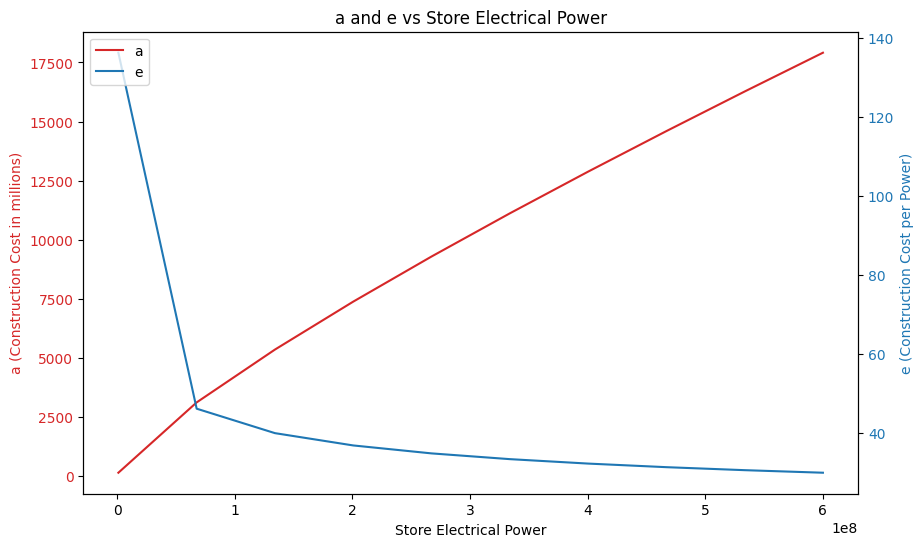

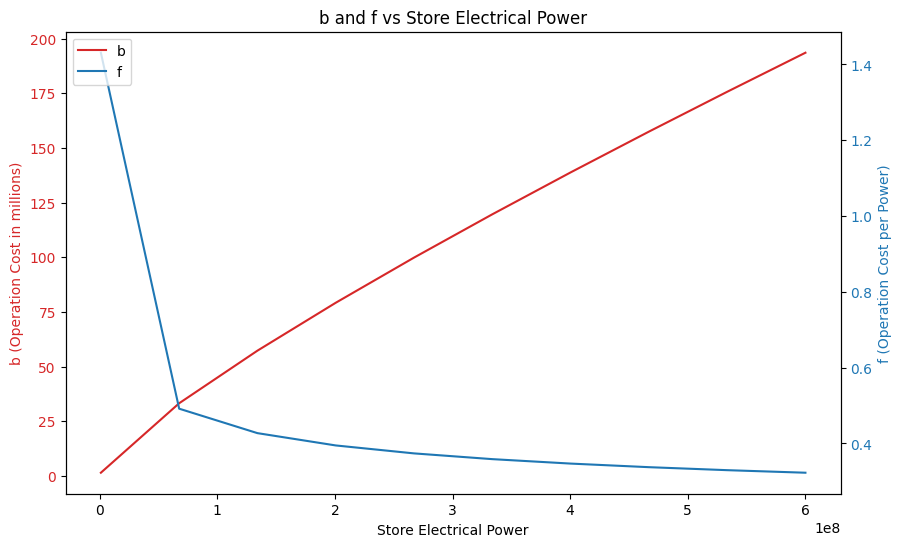

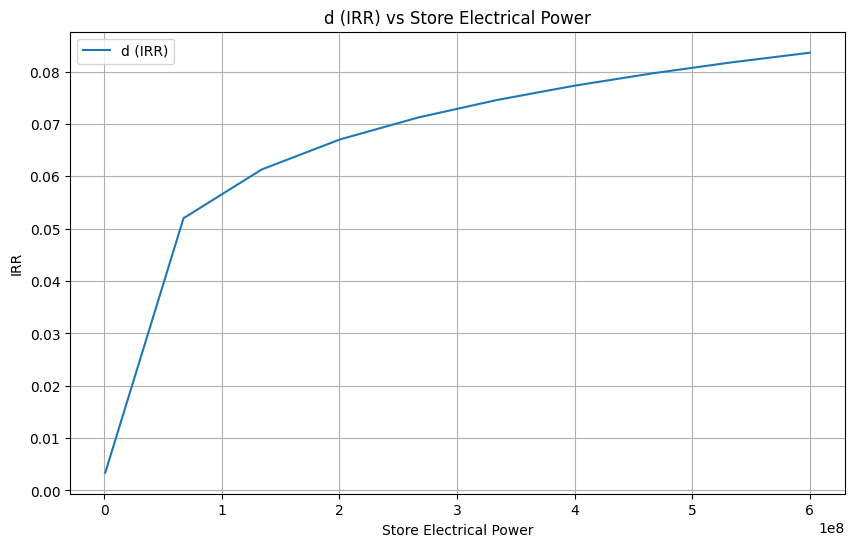

In [8]:
import os
import sys
# CaLRepo = os.environ.get("CaLRepo")
CaLRepo = '/home/zyq0416/workspace/CaL'
# print(CaLRepo)
sys.path.append(f"{CaLRepo}/utilities/")
import math
import json
import numpy as np
from pyCostEstimator import Cost_Estimator
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

## construct cost indictor
construct_labour_cost_indictor = 0.25
engineering_project_cost_indictor = 0.175
TASC_multiplier = 1.13
piping_integration_cost_indictor = 0.05
# 单次储能时间8小时
Single_run_time = 8 * 3600
# 年循环次数（储能2560小时，释能2560小时，年运行时间5120小时
Annual_cycle_count = 320
# 循环极限次数
Limit_cycle_number = 50
# 安全存储比例

# 氢氧化钙价格RMB/t
caoh2_unit_price = 1500
M_cao = 56e-3  # kg/mol
M_caoh2 = 74e-3  # kg/mol
parameters = dict()
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["isentropic_eff_mc"] = 0.88
parameters["t_isentropic_eff_mc"] = 0.92
parameters["mechanical_eff"] = 0.98  # 机械效率
parameters["industrial_waste_heat_t"] = 300  # ℃
parameters["heat_transfer_loss_eff"] = 0.96
parameters["t_amb"] = 20  # 环境温度
parameters["p_amb"] = 101325  # 环境压力

parameters["p_bray_L"] = 7.5e6
parameters["p_water_supply_in"] = 2e5
parameters["water_pressure_drop_rate"] = 100  # 100Pa/m
parameters["water_pipe_length"] = 1000
parameters["water_pump_hydraulic_efficiency"] = 0.75
parameters["water_pump_mechanical_efficiency"] = 0.94

parameters["cao_conversion"] = 0.95  # 氧化钙转化率
parameters["cao_purity"] = 0.98  # 氢氧化钙含量
parameters["dehydrator_eff"] = 0.95  # 脱水器效率
parameters["steam_pressure_loss_ratio"] = 0.01
parameters["convey_consumption"] = 10e3 / 100
parameters["storage_dehydrator_distance"] = 100

parameters["hydrator_eff"] = 0.95  # 水合器器效率
parameters["p_bray_L_B"] = 7.5e6

inputs = {}
inputs["p_bray_H"] = 18716228  # 优化变量1，热泵循环最高压力
inputs["p_bray_M"] = 12481150  # 优化变量2，热泵循环中间压力
inputs["p_Dehy"] = 1e5  # 变量4，反应器压力
inputs["Economic Model Selection"] = 1  # 经济模型选择，1Tesio，2Nathan T
inputs["Compressor power limit"] = 200e6  # 功率界限，影响齿轮离心和滚筒离心模型的选取，单位W，桶式离心需体积流量
inputs["Turbine power limit"] = 35e6
inputs["Dehy_overheating_temperature"] = 20  # 变量2，脱水反应器过热温度
inputs["min_temperature_exchange"] = 15
inputs["min_temperature_HEN"] = 15

inputs["p_bray_H_B"] = 30e6
inputs["p_bray_MH_B"] = 16217752.142109105
inputs["p_bray_ML_B"] = 12217752.142109105
inputs["p_Hydr"] = 1e5
inputs["Hydr_overheating_temperature"] = 40

inputs["Hydr_cao_in"] = 440
inputs["T_X"] = 1

economic_inputs = {}
# economic_inputs["limestone_price"]=70
# economic_inputs["calciner_cost_factor"]=1
economic_inputs["elec_price"] = 0  # 元/千瓦时  ##S6
economic_inputs["hot_price_h"] = 0.1542  # 每千瓦时0.1542元，42.84元/吉焦
economic_inputs["elec_price_h"] = 1.0827
economic_inputs["operation_hours"] = 2560  # hours  ### S9
economic_inputs["discount_ratio"] = 6 / 100  # 8%
economic_inputs["operational_years"] = 60
economic_inputs["operation_labour_cost_indictor"] = 0.025 / 2 * (2 / 3) / 2  # 劳动力比例
# 年运行时间为一般机组的一半,天运行时间为一般机组的2/3，投资成本为一般机组的两倍以上
economic_inputs["maintain_cost_indictor"] = 0.025 / 2 / 2  # 维护比例 0.025,
# 年运行时间为一般机组的一半，投资成本为一般机组的两倍以上故修正

# 定义 Store_electrical_power 的范围
power_range = np.linspace(1e6, 600e6, 10)
a_values = []
e_values = []
b_values = []
f_values = []
d_values = []


for power in power_range:
    parameters["Store_electrical_power"] = power
    cost = Cost_Estimator(parameters)
    results = cost.solve(inputs, economic_inputs)
    a = results["construction"]["total as-spent"] / 1000000
    b = results["operation"]["total as-spent"] / 1000000
    c = results["Annual_operating_income"]
    d = results["IRR"]
    e = results["construction"]["total as-spent"] / parameters["Store_electrical_power"]
    f = results["operation"]["total as-spent"] / parameters["Store_electrical_power"]
    a_values.append(a)
    e_values.append(e)
    b_values.append(b)
    f_values.append(f)
    d_values.append(d)

# 图像1：a 与 e 随 parameters["Store_electrical_power"] 的变化趋势（双Y轴）
fig1, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:red'
ax1.set_xlabel('Store Electrical Power')
ax1.set_ylabel('a (Construction Cost in millions)', color=color)
ax1.plot(power_range, a_values, color=color, label='a')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('e (Construction Cost per Power)', color=color)
ax2.plot(power_range, e_values, color=color, label='e')
ax2.tick_params(axis='y', labelcolor=color)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')
plt.title('a and e vs Store Electrical Power')
plt.show()

# 图像2：b 与 f 随 parameters["Store_electrical_power"] 的变化趋势（双Y轴）
fig2, ax3 = plt.subplots(figsize=(10, 6))
color = 'tab:red'
ax3.set_xlabel('Store Electrical Power')
ax3.set_ylabel('b (Operation Cost in millions)', color=color)
ax3.plot(power_range, b_values, color=color, label='b')
ax3.tick_params(axis='y', labelcolor=color)

ax4 = ax3.twinx()
color = 'tab:blue'
ax4.set_ylabel('f (Operation Cost per Power)', color=color)
ax4.plot(power_range, f_values, color=color, label='f')
ax4.tick_params(axis='y', labelcolor=color)

lines3, labels3 = ax3.get_legend_handles_labels()
lines4, labels4 = ax4.get_legend_handles_labels()
ax4.legend(lines3 + lines4, labels3 + labels4, loc='upper left')
plt.title('b and f vs Store Electrical Power')
plt.show()

# 图像3：d 随 parameters["Store_electrical_power"] 的变化趋势
plt.figure(figsize=(10, 6))
plt.plot(power_range, d_values, label='d (IRR)')
plt.xlabel('Store Electrical Power')
plt.ylabel('IRR')
plt.title('d (IRR) vs Store Electrical Power')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
import os
import sys
# CaLRepo = os.environ.get("CaLRepo")
CaLRepo = '/home/zyq0416/workspace/CaL'
# print(CaLRepo)
sys.path.append(f"{CaLRepo}/utilities/")
import math
import json
import numpy as np
from pyCostEstimator import Cost_Estimator
from scipy.optimize import fsolve
import pandas as pd

## construct cost indictor
construct_labour_cost_indictor = 0.25
engineering_project_cost_indictor = 0.175
TASC_multiplier = 1.13
piping_integration_cost_indictor = 0.05
# 单次储能时间8小时
Single_run_time = 8 * 3600
# 年循环次数（储能2560小时，释能2560小时，年运行时间5120小时
Annual_cycle_count = 320
# 循环极限次数
Limit_cycle_number = 50
# 安全存储比例

# 氢氧化钙价格RMB/t
caoh2_unit_price = 1500
M_cao = 56e-3  # kg/mol
M_caoh2 = 74e-3  # kg/mol
parameters = dict()
flue_gas_composistion = dict()
flue_gas_composistion["co2"] = 0.1338
flue_gas_composistion["o2"] = 0.0384
flue_gas_composistion["n2"] = 0.6975
parameters["flue_gas_composition"] = flue_gas_composistion
parameters["isentropic_eff_mc"] = 0.88
parameters["t_isentropic_eff_mc"] = 0.92
parameters["mechanical_eff"] = 0.98  # 机械效率
parameters["industrial_waste_heat_t"] = 300  # ℃
parameters["heat_transfer_loss_eff"] = 0.96
parameters["t_amb"] = 20  # 环境温度
parameters["p_amb"] = 101325  # 环境压力

parameters["p_bray_L"] = 7.5e6
parameters["p_water_supply_in"] = 2e5
parameters["water_pressure_drop_rate"] = 100  # 100Pa/m
parameters["water_pipe_length"] = 1000
parameters["water_pump_hydraulic_efficiency"] = 0.75
parameters["water_pump_mechanical_efficiency"] = 0.94

parameters["cao_conversion"] = 0.95  # 氧化钙转化率
parameters["cao_purity"] = 0.98  # 氢氧化钙含量
parameters["dehydrator_eff"] = 0.95  # 脱水器效率
parameters["steam_pressure_loss_ratio"] = 0.01
parameters["convey_consumption"] = 10e3 / 100
parameters["storage_dehydrator_distance"] = 100

parameters["hydrator_eff"] = 0.95  # 水合器器效率
parameters["p_bray_L_B"] = 7.5e6

inputs = {}
inputs["p_bray_H"] = 18716228  # 优化变量1，热泵循环最高压力
inputs["p_bray_M"] = 12481150  # 优化变量2，热泵循环中间压力
inputs["p_Dehy"] = 1e5  # 变量4，反应器压力
inputs["Economic Model Selection"] = 2  # 经济模型选择，1Tesio，2Nathan T
inputs["Compressor power limit"] = 200e6  # 功率界限，影响齿轮离心和滚筒离心模型的选取，单位W，桶式离心需体积流量
inputs["Turbine power limit"] = 35e6
inputs["Dehy_overheating_temperature"] = 20  # 变量2，脱水反应器过热温度
inputs["min_temperature_exchange"] = 15
inputs["min_temperature_HEN"] = 15

inputs["p_bray_H_B"] = 30e6
inputs["p_bray_MH_B"] = 16217752.142109105
inputs["p_bray_ML_B"] = 12217752.142109105
inputs["p_Hydr"] = 1e5
inputs["Hydr_overheating_temperature"] = 40

inputs["Hydr_cao_in"] = 440
inputs["T_X"] = 1

economic_inputs = {}
# economic_inputs["limestone_price"]=70
# economic_inputs["calciner_cost_factor"]=1
economic_inputs["elec_price"] = 0  # 元/千瓦时  ##S6
economic_inputs["hot_price_h"] = 0.1542  # 每千瓦时0.1542元，42.84元/吉焦
economic_inputs["elec_price_h"] = 1.0827
economic_inputs["operation_hours"] = 2560  # hours  ### S9
economic_inputs["discount_ratio"] = 6 / 100  # 8%
economic_inputs["operational_years"] = 60
economic_inputs["operation_labour_cost_indictor"] = 0.025 / 2 * (2 / 3) / 2  # 劳动力比例
# 年运行时间为一般机组的一半,天运行时间为一般机组的2/3，投资成本为一般机组的两倍以上
economic_inputs["maintain_cost_indictor"] = 0.025 / 2 / 2  # 维护比例 0.025,
# 年运行时间为一般机组的一半，投资成本为一般机组的两倍以上故修正

# 定义 Store_electrical_power 的范围，这里将范围改为 1 到 600
power_range = np.linspace(1, 50, 20)
b_values = []
f_values = []

for power in power_range:
    parameters["Store_electrical_power"] = power * 1e6  # 因为之前代码中是以 W 为单位，这里要转换
    cost = Cost_Estimator(parameters)
    results = cost.solve(inputs, economic_inputs)
    b = results["LCOE"]
    b_values.append(b)

# 创建 DataFrame
data = {
    'Store Electrical Power (MW)': power_range,
    'b (Operation Cost in millions)': b_values,
}
df = pd.DataFrame(data)

# 将 DataFrame 写入 Excel 文件
excel_file = pd.ExcelWriter('operation_cost_data.xlsx', engine='xlsxwriter')
df.to_excel(excel_file, sheet_name='Operation Cost', index=False)
excel_file.save()

print("数据已成功写入 operation_cost_data.xlsx 文件。")
    

数据已成功写入 operation_cost_data.xlsx 文件。


/tmp/ipykernel_719/560781586.py:118: FutureWarning: save is not part of the public API, usage can give unexpected results and will be removed in a future version
  excel_file.save()
